# Phần 2 - Trực quan hóa và Phân tích dữ liệu

## Câu chuyện chính
1. Nhu cầu có tính mùa vụ rất rõ, trong đó quý 2 là mùa cao điểm của doanh thu và lợi nhuận.
2. Lưu lượng truy cập website có tương quan dương với doanh thu, nên có thể dùng như một chỉ báo sớm để lập kế hoạch bán hàng.
3. Biên lợi nhuận bị bào mòn mạnh khi tỷ trọng doanh thu khuyến mãi tăng cao; đây là điểm rò rỉ lợi nhuận lớn nhất.
4. Trả hàng chủ yếu đến từ vấn đề fit/chất lượng sản phẩm hơn là vấn đề giao hàng.
5. Tồn kho đang bị mất cân bằng: vừa stockout cao vừa overstock cao, hàm ý vấn đề phân bổ tồn kho hơn là chỉ thiếu tổng cung.

In [48]:
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore")


sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

DATA_DIR = Path("dataset")


In [49]:
# Load data
sales = pd.read_csv(DATA_DIR / "sales.csv", parse_dates=["Date"])
orders = pd.read_csv(DATA_DIR / "orders.csv", parse_dates=["order_date"])
order_items = pd.read_csv(DATA_DIR / "order_items.csv", dtype={"promo_id_2": "string"})
payments = pd.read_csv(DATA_DIR / "payments.csv")
shipments = pd.read_csv(DATA_DIR / "shipments.csv", parse_dates=["ship_date", "delivery_date"])
returns = pd.read_csv(DATA_DIR / "returns.csv", parse_dates=["return_date"])
reviews = pd.read_csv(DATA_DIR / "reviews.csv", parse_dates=["review_date"])
products = pd.read_csv(DATA_DIR / "products.csv")
customers = pd.read_csv(DATA_DIR / "customers.csv", parse_dates=["signup_date"])
inventory = pd.read_csv(DATA_DIR / "inventory.csv", parse_dates=["snapshot_date"])
web = pd.read_csv(DATA_DIR / "web_traffic.csv", parse_dates=["date"])
geography = pd.read_csv(DATA_DIR / "geography.csv")

# Feature engineering
sales["profit"] = sales["Revenue"] - sales["COGS"]
sales["margin"] = sales["profit"] / sales["Revenue"]
sales["year"] = sales["Date"].dt.year
sales["month"] = sales["Date"].dt.month
sales["quarter"] = sales["Date"].dt.quarter

order_items = order_items.merge(products[["product_id", "category", "segment", "size", "cogs"]], on="product_id", how="left")
order_items["gross_sales"] = order_items["quantity"] * order_items["unit_price"]
order_items["net_revenue"] = order_items["gross_sales"] - order_items["discount_amount"]
order_items["gross_profit"] = order_items["quantity"] * (order_items["unit_price"] - order_items["cogs"]) - order_items["discount_amount"]
order_items["has_promo"] = order_items["promo_id"].notna() | order_items["promo_id_2"].notna()

order_level = (
    order_items.groupby("order_id", as_index=False)
    .agg(order_revenue=("net_revenue", "sum"), order_profit=("gross_profit", "sum"), discount=("discount_amount", "sum"))
)

orders_enriched = (
    orders.merge(order_level, on="order_id", how="left")
    .merge(payments[["order_id", "payment_value", "installments"]], on="order_id", how="left")
    .merge(geography[["zip", "region"]], on="zip", how="left")
)

returned_orders = returns[["order_id"]].drop_duplicates().assign(returned=1)
orders_enriched = orders_enriched.merge(returned_orders, on="order_id", how="left")
orders_enriched["returned"] = orders_enriched["returned"].fillna(0)

monthly_sales = (
    sales.groupby(pd.Grouper(key="Date", freq="MS"))
    .agg(revenue=("Revenue", "sum"), profit=("profit", "sum"))
)
monthly_sales["margin"] = monthly_sales["profit"] / monthly_sales["revenue"]
monthly_sales["rev_ma12"] = monthly_sales["revenue"].rolling(12).mean()
monthly_sales["month_num"] = monthly_sales.index.month

monthly_web = web.groupby(pd.Grouper(key="date", freq="MS")).agg(sessions=("sessions", "sum"), page_views=("page_views", "sum"))
monthly_demand = monthly_sales.join(monthly_web, how="inner").reset_index().rename(columns={"Date": "month_start", "index": "month_start"})

monthly_promo = (
    orders[["order_id", "order_date"]]
    .merge(order_items[["order_id", "net_revenue", "gross_profit", "has_promo"]], on="order_id", how="left")
    .groupby([pd.Grouper(key="order_date", freq="MS"), "has_promo"])
    .agg(revenue=("net_revenue", "sum"), profit=("gross_profit", "sum"))
    .reset_index()
)
monthly_promo["margin"] = monthly_promo["profit"] / monthly_promo["revenue"]
monthly_promo = monthly_promo.pivot(index="order_date", columns="has_promo", values=["revenue", "margin"])
monthly_promo.columns = [f"{metric}_{'promo' if flag else 'nonpromo'}" for metric, flag in monthly_promo.columns]
monthly_promo["promo_rev_share"] = monthly_promo["revenue_promo"] / (monthly_promo["revenue_promo"] + monthly_promo["revenue_nonpromo"])
monthly_promo["overall_margin"] = (
    monthly_promo["revenue_promo"] * monthly_promo["margin_promo"]
    + monthly_promo["revenue_nonpromo"] * monthly_promo["margin_nonpromo"]
) / (monthly_promo["revenue_promo"] + monthly_promo["revenue_nonpromo"])
monthly_promo = monthly_promo.reset_index()

returns_with_product = returns.merge(products[["product_id", "category", "segment", "size"]], on="product_id", how="left")
return_reason_summary = (
    returns.groupby("return_reason", as_index=False)
    .agg(records=("return_id", "count"), refund_amount=("refund_amount", "sum"))
    .sort_values("refund_amount", ascending=False)
)
size_reason = pd.crosstab(returns_with_product["size"], returns_with_product["return_reason"], normalize="index") * 100

inventory_monthly = (
    inventory.groupby("snapshot_date", as_index=False)
    .agg(
        stockout_rate=("stockout_flag", "mean"),
        overstock_rate=("overstock_flag", "mean"),
        fill_rate=("fill_rate", "mean"),
        days_of_supply=("days_of_supply", "mean")
    )
)

quarter_summary = sales.groupby("quarter", as_index=False).agg(revenue=("Revenue", "sum"), profit=("profit", "sum"))
quarter_summary["revenue_share"] = quarter_summary["revenue"] / quarter_summary["revenue"].sum()

region_summary = orders_enriched.groupby("region", as_index=False).agg(revenue=("order_revenue", "sum"), orders=("order_id", "count"), aov=("order_revenue", "mean"))
region_summary = region_summary.sort_values("revenue", ascending=False)
region_summary["revenue_share"] = region_summary["revenue"] / region_summary["revenue"].sum()

source_summary = orders_enriched.groupby("order_source", as_index=False).agg(revenue=("order_revenue", "sum"), orders=("order_id", "count"))
source_summary = source_summary.sort_values("revenue", ascending=False)
source_summary["revenue_share"] = source_summary["revenue"] / source_summary["revenue"].sum()


## 1. Executive summary
Phần này đặt nền cho bài toán: quy mô kinh doanh, tính mùa vụ và các điểm rò rỉ giá trị lớn nhất để ưu tiên hành động.

,Metric,Value
0,Tổng doanh thu 2012-2022,"16,430,476,586"
1,Tổng lợi nhuận gộp 2012-2022,"2,267,026,066"
2,Biên lợi nhuận gộp toàn kỳ,13.8%
3,Tỷ trọng doanh thu Q2,36.1%
4,Tỷ trọng lợi nhuận Q2,45.0%
5,Tương quan doanh thu tháng và sessions,0.46


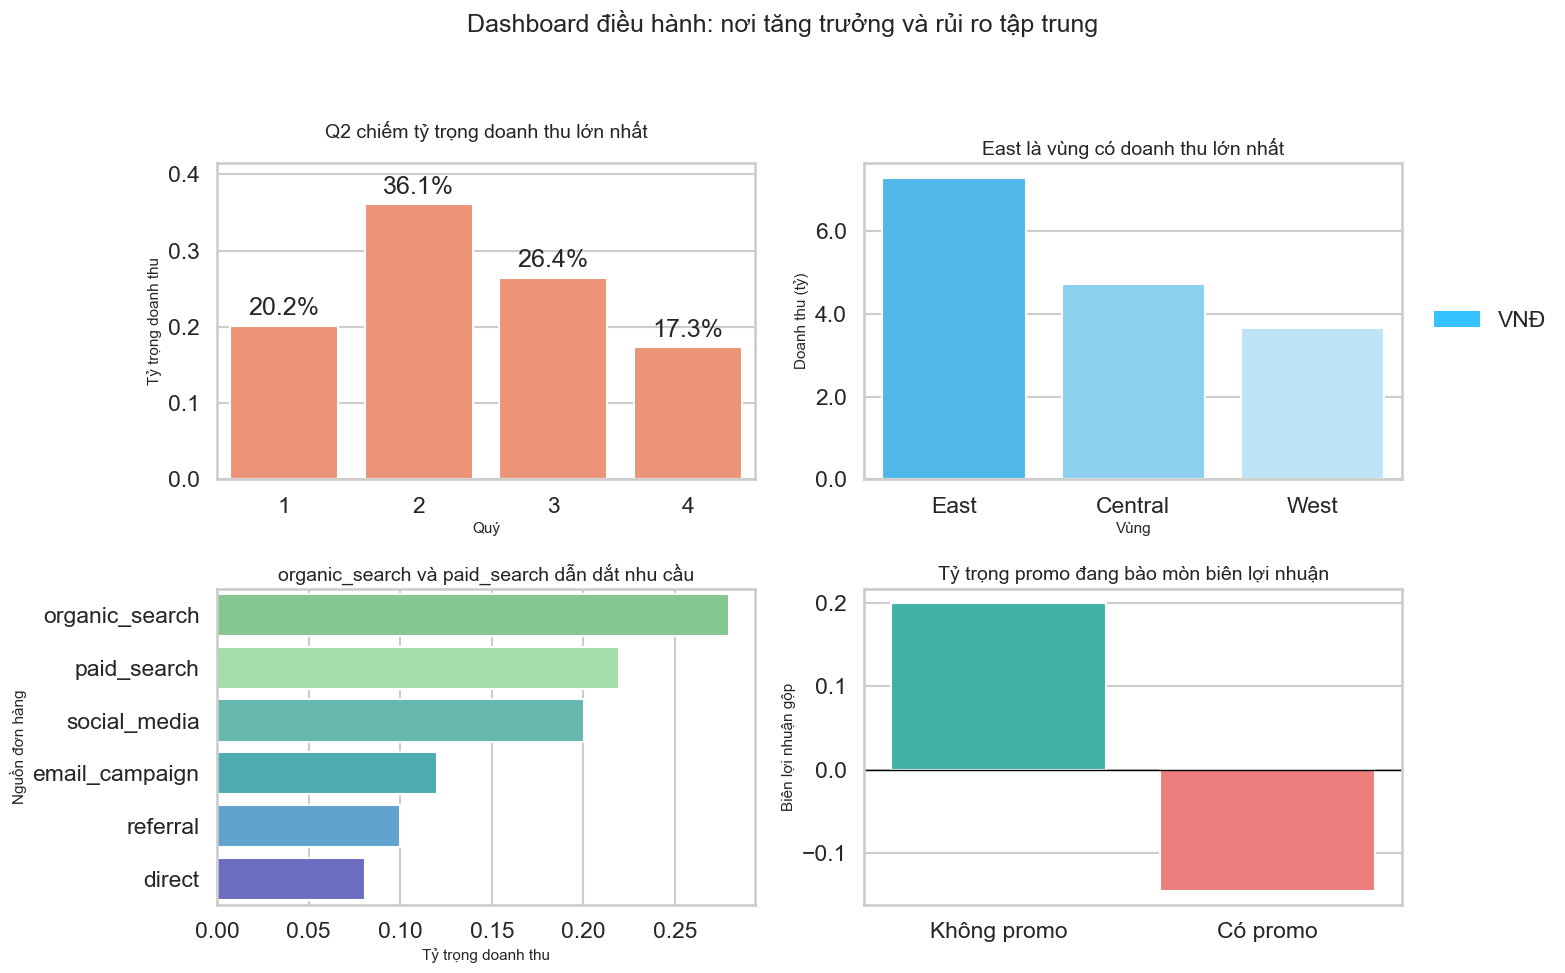

In [50]:
summary_cards = pd.DataFrame(
    {
        "Metric": [
            "Tổng doanh thu 2012-2022",
            "Tổng lợi nhuận gộp 2012-2022",
            "Biên lợi nhuận gộp toàn kỳ",
            "Tỷ trọng doanh thu Q2",
            "Tỷ trọng lợi nhuận Q2",
            "Tương quan doanh thu tháng và sessions"
        ],
        "Value": [
            f"{sales['Revenue'].sum():,.0f}",
            f"{sales['profit'].sum():,.0f}",
            f"{sales['profit'].sum() / sales['Revenue'].sum():.1%}",
            f"{(sales.loc[sales['quarter'] == 2, 'Revenue'].sum() / sales['Revenue'].sum()):.1%}",
            f"{(sales.loc[sales['quarter'] == 2, 'profit'].sum() / sales['profit'].sum()):.1%}",
            f"{monthly_demand['revenue'].corr(monthly_demand['sessions']):.2f}"
        ]
    }
)

display(summary_cards)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Dashboard điều hành: nơi tăng trưởng và rủi ro tập trung", fontsize=18, y=0.98)

sns.barplot(data=quarter_summary, x="quarter", y="revenue_share", color="#ff8a65", ax=axes[0, 0])
axes[0, 0].set_title("Q2 chiếm tỷ trọng doanh thu lớn nhất", pad=18)
axes[0, 0].set_xlabel("Quý")
axes[0, 0].set_ylabel("Tỷ trọng doanh thu")
axes[0, 0].set_ylim(0, quarter_summary['revenue_share'].max() * 1.15)
for container in axes[0, 0].containers:
    axes[0, 0].bar_label(container, fmt="%.1f%%", labels=[f"{v:.1%}" for v in quarter_summary['revenue_share']], padding=4)

sns.barplot(data=region_summary, x="region", y="revenue", palette=["#36c2ff", "#7cd6ff", "#b6e7ff"], ax=axes[0, 1])
axes[0, 1].set_title("East là vùng có doanh thu lớn nhất")
axes[0, 1].set_xlabel("Vùng")
axes[0, 1].set_ylabel("Doanh thu (tỷ)")
axes[0, 1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"{x/1e9:.1f}"))
axes[0, 1].legend(handles=[matplotlib.patches.Patch(facecolor="#36c2ff", edgecolor="none", label="VNĐ")], loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

top_sources = source_summary.copy()
sns.barplot(data=top_sources, y="order_source", x="revenue_share", palette=["#7bd389", "#9be7a1", "#58c4b8", "#3fbac2", "#4ea8de", "#5e60ce"], ax=axes[1, 0])
axes[1, 0].set_title("organic_search và paid_search dẫn dắt nhu cầu")
axes[1, 0].set_xlabel("Tỷ trọng doanh thu")
axes[1, 0].set_ylabel("Nguồn đơn hàng")

promo_view = pd.DataFrame({
    "line_type": ["Không promo", "Có promo"],
    "margin": [
        order_items.loc[~order_items['has_promo'], 'gross_profit'].sum() / order_items.loc[~order_items['has_promo'], 'net_revenue'].sum(),
        order_items.loc[order_items['has_promo'], 'gross_profit'].sum() / order_items.loc[order_items['has_promo'], 'net_revenue'].sum(),
    ]
})
sns.barplot(data=promo_view, x="line_type", y="margin", palette=["#2ec4b6", "#ff6b6b"], ax=axes[1, 1])
axes[1, 1].axhline(0, color="black", linewidth=1)
axes[1, 1].set_title("Tỷ trọng promo đang bào mòn biên lợi nhuận")
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("Biên lợi nhuận gộp")

fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


**Nhận xét nhanh**

- Q2 đóng góp khoảng 36% doanh thu và 45% lợi nhuận toàn kỳ, cho thấy đây không chỉ là mùa bán nhiều mà còn là mùa bán hiệu quả.
- Lượng truy cập (sessions) website có tương quan dương mức vừa với doanh thu theo tháng (`r ≈ 0.46`), đủ để sử dụng như một chỉ báo vận hành sớm.
- Do đó, bài toán kinh doanh không phải là tăng doanh thu bằng mọi giá, mà là **duy trì biên lợi nhuận trong mùa cao điểm** và **phân bổ tồn kho đúng thời điểm, đúng SKU**.

## 2. Nhu cầu: Doanh thu mang tính mùa vụ rõ rệt

Phần này trả lời câu hỏi `Điều gì đã xảy ra?` và một phần `Điều gì có khả năng sẽ xảy ra?`.

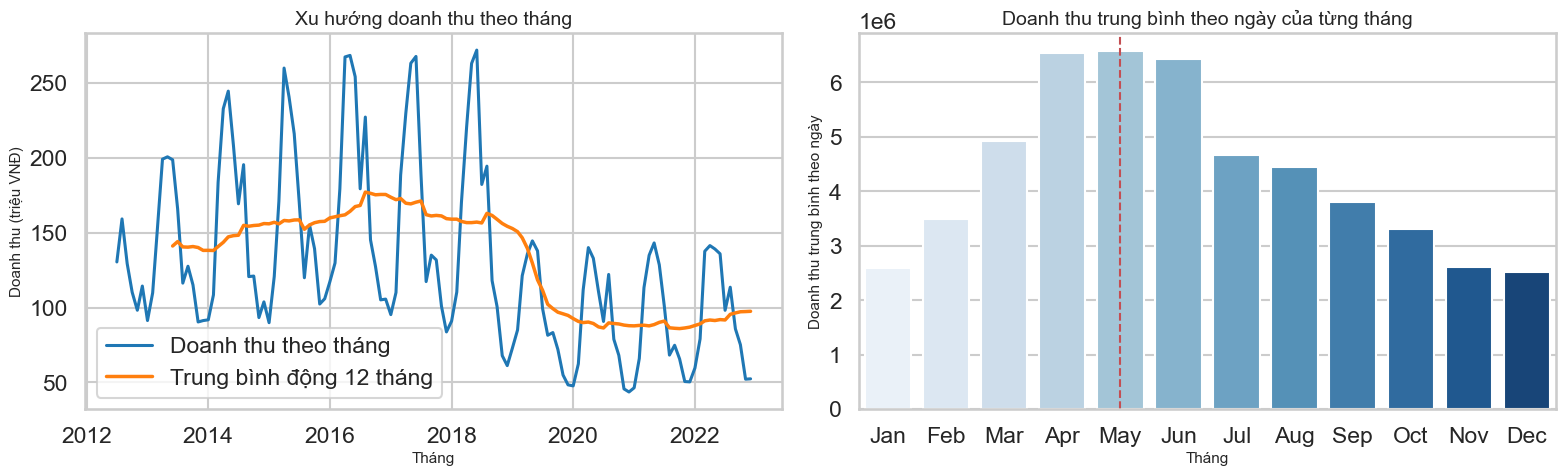

In [51]:
monthly_avg = sales.groupby("month", as_index=False).agg(avg_revenue=("Revenue", "mean"), avg_margin=("margin", "mean"))
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.lineplot(x=monthly_sales.index, y=monthly_sales["revenue"] / 1e6, ax=axes[0], color="#1f77b4", linewidth=2.2, label="Doanh thu theo tháng")
sns.lineplot(x=monthly_sales.index, y=monthly_sales["rev_ma12"] / 1e6, ax=axes[0], color="#ff7f0e", linewidth=2.5, label="Trung bình động 12 tháng")
axes[0].set_title("Xu hướng doanh thu theo tháng")
axes[0].set_xlabel("Tháng")
axes[0].set_ylabel("Doanh thu (triệu VNĐ)")
axes[0].legend(frameon=True)

sns.barplot(data=monthly_avg, x="month", y="avg_revenue", palette="Blues", ax=axes[1])
axes[1].set_title("Doanh thu trung bình theo ngày của từng tháng")
axes[1].set_xlabel("Tháng")
axes[1].set_ylabel("Doanh thu trung bình theo ngày")
axes[1].set_xticklabels(month_labels)
peak_month = int(monthly_avg.loc[monthly_avg['avg_revenue'].idxmax(), 'month'])
axes[1].axvline(peak_month - 1, color="#c44e52", linestyle="--", linewidth=1.5)

plt.tight_layout()
fig.subplots_adjust(top=0.92)
plt.show()


**Key findings**

- Doanh thu không phát triển đều theo tháng; mức cầu tập trung rất mạnh vào `tháng 4-6`, đặc biệt tháng 5 là đỉnh cao.
- Nếu nhìn ở cấp quý, `Q2` tạo ra `36.1%` doanh thu và `45.0%` lợi nhuận, vượt xa các quý còn lại. Điều này cho thấy nhuận khả năng cao nhất ở giai đoạn này.
- Mùa cuối năm không phải động cơ lợi nhuận: tháng 12 có doanh thu không quá thấp nhưng biên lợi nhuận trung bình rất yếu so với tháng 5 và tháng 10.

**Business implication**

- Kế hoạch marketing, tồn kho và vận hành cần đặt tầm nhìn theo mùa vụ, không nên phân bổ ngân sách đều theo năm.
- Q2 nên là mùa ưu tiên cho các SKU biên cao và các chiến dịch tăng trưởng chất lượng; Q4 cần đặt mục tiêu bảo vệ margin, tránh đẩy doanh thu bằng giảm giá rộng.

## 3. Traffic là chỉ báo sớm cho nhu cầu

Phần này là `Diagnostic + Predictive`: traffic có liên quan đến doanh thu đến đâu, và có thể dùng để dự báo vận hành sớm hay không?

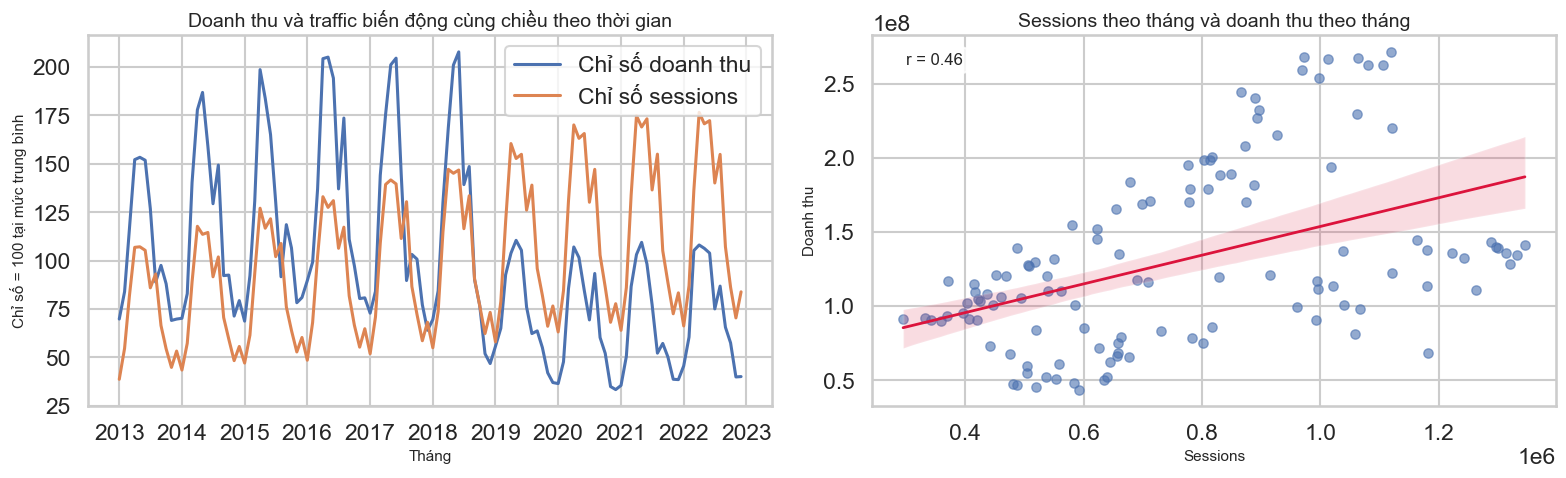

Tương quan Pearson giữa sessions theo tháng và doanh thu theo tháng: 0.458


In [52]:
plot_df = monthly_demand.copy()
plot_df["revenue_idx"] = plot_df["revenue"] / plot_df["revenue"].mean() * 100
plot_df["sessions_idx"] = plot_df["sessions"] / plot_df["sessions"].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.lineplot(data=plot_df, x="month_start", y="revenue_idx", ax=axes[0], label="Chỉ số doanh thu", linewidth=2.2)
sns.lineplot(data=plot_df, x="month_start", y="sessions_idx", ax=axes[0], label="Chỉ số sessions", linewidth=2.2)
axes[0].set_title("Doanh thu và traffic biến động cùng chiều theo thời gian")
axes[0].set_xlabel("Tháng")
axes[0].set_ylabel("Chỉ số = 100 tại mức trung bình")
axes[0].legend(frameon=True)

sns.regplot(data=plot_df, x="sessions", y="revenue", scatter_kws={"alpha": 0.6, "s": 45}, line_kws={"color": "crimson", "linewidth": 2}, ax=axes[1])
axes[1].set_title("Sessions theo tháng và doanh thu theo tháng")
axes[1].set_xlabel("Sessions")
axes[1].set_ylabel("Doanh thu")
axes[1].text(0.05, 0.92, f"r = {plot_df['sessions'].corr(plot_df['revenue']):.2f}", transform=axes[1].transAxes, fontsize=12, bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

plt.tight_layout()
fig.subplots_adjust(top=0.92)
plt.show()

print(f"Tương quan Pearson giữa sessions theo tháng và doanh thu theo tháng: {plot_df['sessions'].corr(plot_df['revenue']):.3f}")


**Key findings**

- Sessions và doanh thu đi cùng chiều khá rõ qua thời gian; hệ số tương quan tháng đạt `~0.46`.
- Điều này chưa đủ để nói traffic là nguyên nhân duy nhất, nhưng đủ mạnh để xem web traffic là một `leading operational indicator`.
- Khi sessions bắt đầu bùng lên trước mùa cao điểm, doanh nghiệp có thể kích hoạt sớm các quyết định về tồn kho, staffing và mức khuyến mãi.

**Business implication / predictive use**

- Có thể đặt ngưỡng cảnh báo theo tháng: nếu sessions vượt đường trung bình 3 tháng gần nhất một mức nhất định, đội vận hành cần tăng mức sẵn sàng tồn kho cho nhóm SKU chủ lực.
- Vì traffic chỉ giải thích một phần doanh thu, doanh nghiệp nên ghép nó với lịch mùa vụ và lịch promo để dự báo gần thực tế hơn.

## 4. Margin leakage: Khuyến mãi đang mua doanh thu bằng lợi nhuận

Đây là phần `Diagnostic` rõ nhất trong bộ dữ liệu và cũng là nơi có thể đưa ra khuyến nghị `Prescriptive` mạnh nhất.

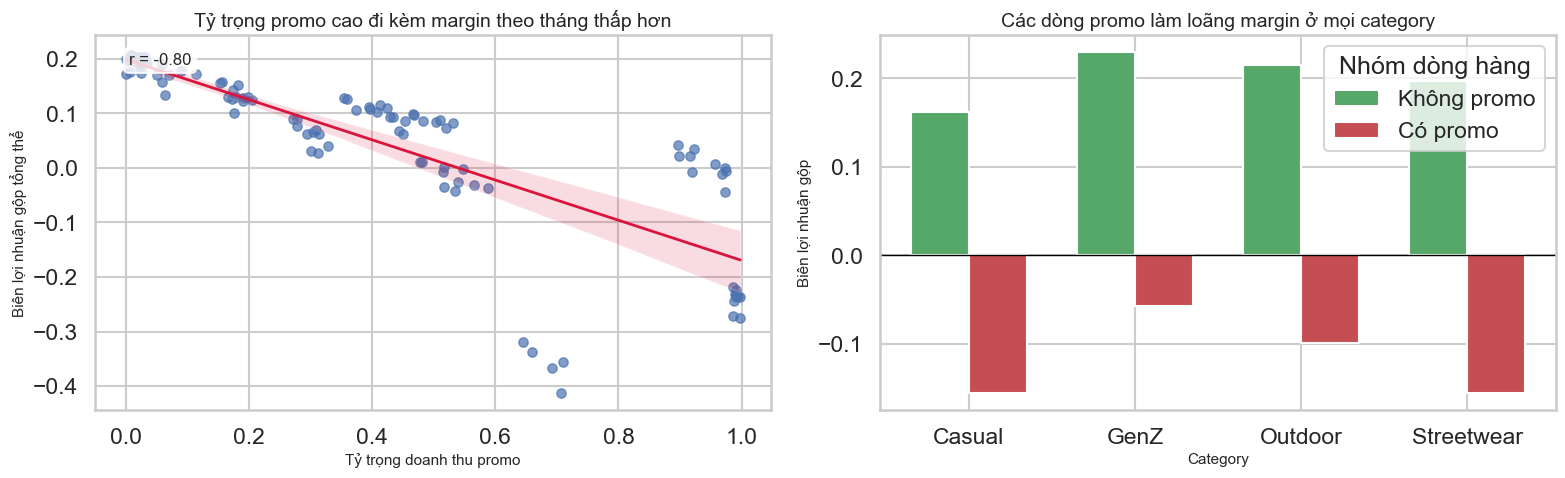

,Nhóm dòng hàng,Doanh thu,Lợi nhuận gộp,Margin
0,Không promo,1.099504e+10,2.195015e+09,0.199637
1,Có promo,4.685830e+09,-6.775966e+08,-0.144605


Tương quan giữa tỷ trọng doanh thu promo và margin theo tháng: -0.802


In [53]:
promo_margin = (
    order_items.groupby("has_promo", as_index=False)
    .agg(revenue=("net_revenue", "sum"), gross_profit=("gross_profit", "sum"))
)
promo_margin["margin"] = promo_margin["gross_profit"] / promo_margin["revenue"]
promo_margin["segment"] = promo_margin["has_promo"].map({False: "Không promo", True: "Có promo"})

category_promo = (
    order_items.groupby(["category", "has_promo"], as_index=False)
    .agg(revenue=("net_revenue", "sum"), gross_profit=("gross_profit", "sum"))
)
category_promo["margin"] = category_promo["gross_profit"] / category_promo["revenue"]
category_promo["segment"] = category_promo["has_promo"].map({False: "Không promo", True: "Có promo"})

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

promo_scatter = monthly_promo.dropna(subset=["promo_rev_share", "overall_margin"]).copy()
sns.regplot(data=promo_scatter, x="promo_rev_share", y="overall_margin", scatter_kws={"alpha": 0.7, "s": 45}, line_kws={"color": "crimson", "linewidth": 2}, ax=axes[0])
axes[0].set_title("Tỷ trọng promo cao đi kèm margin theo tháng thấp hơn")
axes[0].set_xlabel("Tỷ trọng doanh thu promo")
axes[0].set_ylabel("Biên lợi nhuận gộp tổng thể")
axes[0].text(0.05, 0.92, f"r = {promo_scatter['promo_rev_share'].corr(promo_scatter['overall_margin']):.2f}", transform=axes[0].transAxes, fontsize=12, bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

category_plot = category_promo.pivot(index="category", columns="segment", values="margin").reindex(sorted(category_promo["category"].unique()))
x = np.arange(len(category_plot.index))
width = 0.35
axes[1].bar(x - width / 2, category_plot["Không promo"], width=width, label="Không promo", color="#55a868")
axes[1].bar(x + width / 2, category_plot["Có promo"], width=width, label="Có promo", color="#c44e52")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Các dòng promo làm loãng margin ở mọi category")
axes[1].set_xlabel("Category")
axes[1].set_ylabel("Biên lợi nhuận gộp")
axes[1].set_xticks(x)
axes[1].set_xticklabels(category_plot.index)
axes[1].legend(title="Nhóm dòng hàng")

plt.tight_layout()
fig.subplots_adjust(top=0.92)
plt.show()

promo_table = pd.DataFrame(
    {
        "Nhóm dòng hàng": ["Không promo", "Có promo"],
        "Doanh thu": [
            order_items.loc[~order_items['has_promo'], 'net_revenue'].sum(),
            order_items.loc[order_items['has_promo'], 'net_revenue'].sum()
        ],
        "Lợi nhuận gộp": [
            order_items.loc[~order_items['has_promo'], 'gross_profit'].sum(),
            order_items.loc[order_items['has_promo'], 'gross_profit'].sum()
        ]
    }
)
promo_table["Margin"] = promo_table["Lợi nhuận gộp"] / promo_table["Doanh thu"]
display(promo_table)
print(f"Tương quan giữa tỷ trọng doanh thu promo và margin theo tháng: {monthly_promo['promo_rev_share'].corr(monthly_promo['overall_margin']):.3f}")


**Key findings**

- Không có promo, gross margin đạt xấp xỉ `20.0%`; có promo, gross margin chuyển thành `-14.5%`.
- Tổng gross profit của nhóm promo trong toàn kỳ là `âm ~677.6M`, nghĩa là doanh nghiệp đang có nhiều tháng mua doanh thu bằng cách hy sinh lợi nhuận.
- Tỷ trọng doanh thu promo theo tháng có tương quan âm rất mạnh với margin tổng (`corr ≈ -0.80`).
- Việc này xuất hiện ở tất cả category, không chỉ một ngách sản phẩm. Nghĩa là vấn đề nằm ở cơ chế promo, không phải chỉ ở một nhóm hàng lẻ.

**Prescriptive recommendation**

- Chuyển từ `broad discounting` sang `guardrail discounting`: đặt trần discount theo gross margin dự kiến của SKU/category.
- Ưu tiên promo cho mục tiêu giải phóng tồn kho chậm, cross-sell hoặc thu hút khách mới; không dùng promo đại trà để đẩy doanh thu Q4.
- Vì promo lines đang âm `~677.6M` gross profit, chỉ cần đưa nhóm này về mức hòa vốn đã là một cơ hội cải thiện lợi nhuận rất lớn. Đây là đòn bẩy tài chính lớn nhất trong toàn bộ bài phân tích.

## 5. Returns: Vấn đề chính là fit và chất lượng sản phẩm, không phải giao hàng

Phần này nhằm tìm `Why did it happen?` cho sự thất thoát sau bán hàng.

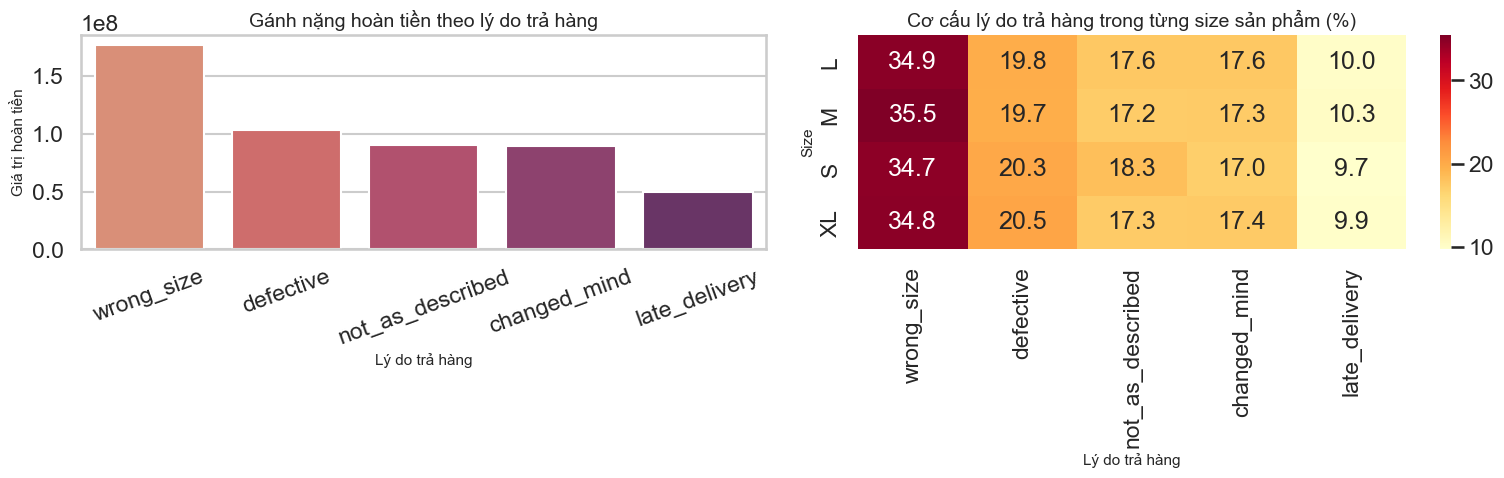

,return_reason,records,refund_amount,share_of_refunds
4,wrong_size,13967,1.766872e+08,0.346039
1,defective,8020,1.035991e+08,0.202897
3,not_as_described,7035,9.065319e+07,0.177543
0,changed_mind,6931,8.972176e+07,0.175719
2,late_delivery,3986,4.993721e+07,0.097801


,category,return_records,refund_amount
3,Streetwear,21799,4.067082e+08
2,Outdoor,14720,7.871751e+07
0,Casual,1294,1.402709e+07
1,GenZ,2126,1.114565e+07


In [54]:
reason_order = return_reason_summary["return_reason"].tolist()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

reason_plot = return_reason_summary.set_index("return_reason").loc[reason_order].reset_index()
sns.barplot(data=reason_plot, x="return_reason", y="refund_amount", palette="flare", ax=axes[0])
axes[0].set_title("Gánh nặng hoàn tiền theo lý do trả hàng")
axes[0].set_xlabel("Lý do trả hàng")
axes[0].set_ylabel("Giá trị hoàn tiền")
axes[0].tick_params(axis="x", rotation=20)

heatmap_data = size_reason[reason_order]
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlOrRd", cbar=True, ax=axes[1])
axes[1].set_title("Cơ cấu lý do trả hàng trong từng size sản phẩm (%)")
axes[1].set_xlabel("Lý do trả hàng")
axes[1].set_ylabel("Size")

plt.tight_layout()
fig.subplots_adjust(top=0.92)
plt.show()

return_reason_summary["share_of_refunds"] = return_reason_summary["refund_amount"] / return_reason_summary["refund_amount"].sum()
return_category_summary = (
    returns_with_product.groupby("category", as_index=False)
    .agg(return_records=("return_id", "count"), refund_amount=("refund_amount", "sum"))
    .sort_values("refund_amount", ascending=False)
)
display(return_reason_summary)
display(return_category_summary)


**Key findings**

- `wrong_size` là lý do trả hàng lớn nhất theo cả số record lẫn refund amount (`~176.7M`).
- Ba nhóm `wrong_size`, `defective`, `not_as_described` chiếm khoảng `72.6%` tổng refund burden. Đây là cụm vấn đề liên quan trực tiếp đến fit, mô tả sản phẩm và chất lượng.
- `late_delivery` chỉ chiếm khoảng `10%` refund burden, nên nếu ngân sách cải thiện có hạn, doanh nghiệp không nên ưu tiên giao hàng trước fit/QC.
- Heatmap cho thấy `wrong_size` là vấn đề đầu bảng ở tất cả S, M, L, XL; do đó giải pháp nên ở cấp danh mục và trang sản phẩm, không phải chỉ sửa một size đơn lẻ.
- `Streetwear` và `Outdoor` cộng nhau chiếm khoảng `95.1%` refund value, vì vậy đây là hai nhóm nên được chọn làm nơi pilot đầu tiên.

**Prescriptive recommendation**

- Ưu tiên 3 việc: size guide chi tiết hơn, review/UGC theo body fit, và checklist QC cho các nhóm trả hàng cao.
- Nếu giảm được chỉ `10%` refund từ `wrong_size + defective`, doanh nghiệp có thể giữ lại xấp xỉ `28.0M` refund value (`10% * 280.3M`).
- Nên thử nghiệm A/B trên trang product detail cho Streetwear và Outdoor vì đây là hai nhóm đóng góp phần lớn volume và returns.

## 5.1. Chọn nơi pilot: category nào cần ưu tiên trước?

Thay vì sửa đồng loạt, cần xác định category có tác động kinh doanh lớn nhất để làm pilot đầu tiên.

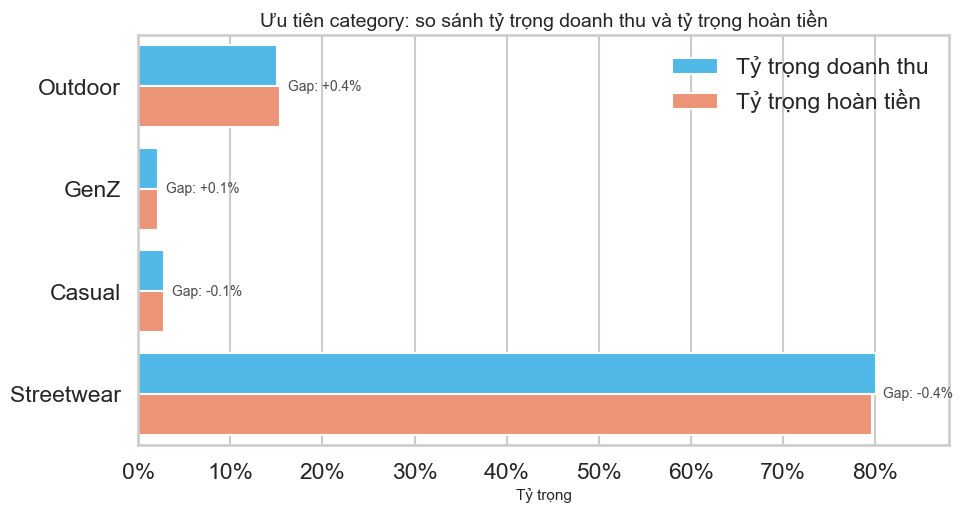

In [55]:
category_priority = (
    order_items.groupby("category", as_index=False)
    .agg(revenue=("net_revenue", "sum"), gross_profit=("gross_profit", "sum"))
    .merge(returns_with_product.groupby("category", as_index=False).agg(refund_amount=("refund_amount", "sum")), on="category", how="left")
)
category_priority["refund_amount"] = category_priority["refund_amount"].fillna(0)
category_priority["revenue_share"] = category_priority["revenue"] / category_priority["revenue"].sum()
category_priority["refund_share"] = category_priority["refund_amount"] / category_priority["refund_amount"].sum()
category_priority["priority_gap"] = category_priority["refund_share"] - category_priority["revenue_share"]
category_priority = category_priority.sort_values("priority_gap", ascending=False)

plot_df = category_priority.melt(
    id_vars=["category", "priority_gap"],
    value_vars=["revenue_share", "refund_share"],
    var_name="metric",
    value_name="share"
)
plot_df["metric"] = plot_df["metric"].map({"revenue_share": "Tỷ trọng doanh thu", "refund_share": "Tỷ trọng hoàn tiền"})

fig, ax = plt.subplots(figsize=(10, 5.5))
sns.barplot(
    data=plot_df,
    y="category",
    x="share",
    hue="metric",
    palette=["#36c2ff", "#ff8a65"],
    ax=ax
)
ax.set_title("Ưu tiên category: so sánh tỷ trọng doanh thu và tỷ trọng hoàn tiền")
ax.set_xlabel("Tỷ trọng")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.set_xlim(0, plot_df["share"].max() + 0.08)
ax.legend(title="", loc="upper right", frameon=False)

for idx, row in category_priority.reset_index(drop=True).iterrows():
    ax.text(
        max(row["revenue_share"], row["refund_share"]) + 0.008,
        idx,
        f"Gap: {row['priority_gap']:+.1%}",
        va="center",
        fontsize=10,
        color="#4a4a4a"
    )

plt.tight_layout()
fig.subplots_adjust(top=0.9)
plt.show()


**Why this matters**

- Visual này biến insight thành quyết định ưu tiên. `Streetwear` là điểm nóng số 1: vừa đóng góp doanh thu rất lớn, vừa gánh refund burden lớn nhất.
- `Outdoor` là điểm nóng số 2 và nên là cụm pilot tiếp theo. Cách nhìn này giúp doanh nghiệp tránh dàn trải nguồn lực cho các category nhỏ hơn.

## 6. Inventory paradox: vừa stockout cao vừa overstock cao

Đây là phần kết nối nhiều bảng dữ liệu để đưa ra khuyến nghị vận hành. Nếu chỉ nhìn doanh thu sẽ bỏ qua nghịch lý này.

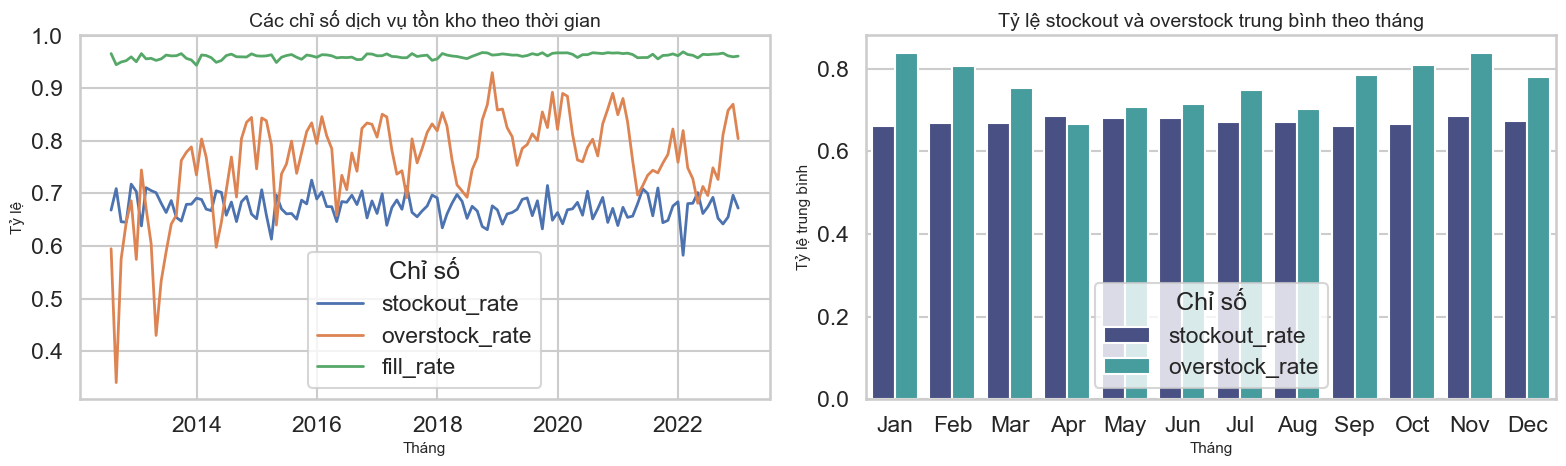

,Metric,Value
0,Average monthly stockout rate,67.3%
1,Average monthly overstock rate,76.4%
2,Months with stockout > 65% and overstock > 80%,39


In [56]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

inventory_long_ts = inventory_monthly.melt(id_vars="snapshot_date", value_vars=["stockout_rate", "overstock_rate", "fill_rate"], var_name="metric", value_name="value")
sns.lineplot(data=inventory_long_ts, x="snapshot_date", y="value", hue="metric", linewidth=2, ax=axes[0])
axes[0].set_title("Các chỉ số dịch vụ tồn kho theo thời gian")
axes[0].set_xlabel("Tháng")
axes[0].set_ylabel("Tỷ lệ")
axes[0].legend(title="Chỉ số")

inventory_monthly_plot = inventory_monthly.copy()
inventory_monthly_plot["month"] = inventory_monthly_plot["snapshot_date"].dt.month
inventory_monthly_avg = inventory_monthly_plot.groupby("month", as_index=False).agg(stockout_rate=("stockout_rate", "mean"), overstock_rate=("overstock_rate", "mean"))
inventory_long = inventory_monthly_avg.melt(id_vars="month", value_vars=["stockout_rate", "overstock_rate"], var_name="metric", value_name="value")
sns.barplot(data=inventory_long, x="month", y="value", hue="metric", palette="mako", ax=axes[1])
axes[1].set_title("Tỷ lệ stockout và overstock trung bình theo tháng")
axes[1].set_xlabel("Tháng")
axes[1].set_ylabel("Tỷ lệ trung bình")
axes[1].set_xticklabels(month_labels)
axes[1].legend(title="Chỉ số")

plt.tight_layout()
plt.show()

inventory_summary = pd.DataFrame(
    {
        "Metric": [
            "Average monthly stockout rate",
            "Average monthly overstock rate",
            "Months with stockout > 65% and overstock > 80%"
        ],
        "Value": [
            f"{inventory_monthly['stockout_rate'].mean():.1%}",
            f"{inventory_monthly['overstock_rate'].mean():.1%}",
            int(((inventory_monthly['stockout_rate'] > 0.65) & (inventory_monthly['overstock_rate'] > 0.80)).sum())
        ]
    }
)
display(inventory_summary)


**Key findings**

- Trung bình theo tháng, `stockout rate ~67.3%` trong khi `overstock rate ~76.4%`. Hai chỉ số cùng cao một cách bất thường.
- Có `39` tháng vừa stockout > 65% vừa overstock > 80%. Điều này cho thấy bài toán không nằm ở tổng mức tồn kho, mà nằm ở **phân bổ tồn kho sai SKU / sai thời điểm**.
- Trong bối cảnh Q2 là mùa đóng góp doanh thu và lợi nhuận lớn nhất, tồn kho phân bổ sai ngay trước và trong mùa cao điểm có thể làm mất cả doanh thu lẫn margin.

**Prescriptive recommendation**

- Chuyển từ logic mua hàng tổng hợp sang logic `SKU-season allocation`: ưu tiên phân bổ tồn kho cho các SKU chủ lực trước Q2 thay vì đẩy tồn rộng ở cuối năm.
- Lập dashboard cảnh báo 2 đầu: SKU có traffic tăng nhanh nhưng days_of_supply thấp, và SKU có days_of_supply quá cao trong mùa thấp điểm.
- Khi kết hợp cùng insight promo, thông điệp quan trọng là: không nên dùng giảm giá đại trà để chữa bài toán tồn kho. Vấn đề cốt lõi là phân bổ hàng tồn, không phải chỉ thanh lý.

## 7. Kết luận quản trị và action plan

Nếu chỉ được ưu tiên 3 việc trong 90 ngày tới, thứ tự đề xuất là:

1. **Sửa cơ chế promo**: áp trần discount theo category/SKU margin, vì đây là nguồn rò rỉ lợi nhuận lớn nhất và đã được chứng minh định lượng.
2. **Giảm returns do fit/QC**: tập trung vào `wrong_size`, `defective`, `not_as_described`; chỉ cần cắt 10% refund ở hai nhóm đầu đã có thể giữ lại ~28.0M.
3. **Tái phân bổ tồn kho trước Q2**: dùng sessions và lịch mùa vụ làm chỉ báo sớm để đẩy đúng SKU vào đúng thời điểm.

### Tại sao câu chuyện này có giá trị kinh doanh?

- Nó không dừng lại ở việc mô tả doanh thu lên/xuống, mà chỉ ra **doanh thu nào nên theo đuổi**, **doanh thu nào đang phá margin**, và **hệ thống vận hành cần thay đổi ở đâu**.
- Các khuyến nghị đều có liên kết trực tiếp với con số cụ thể trong dữ liệu, phù hợp với mức chấm điểm cao nhất cho phần prescriptive.